# 10b - Inspect Crop Quality
Kiểm tra chất lượng crop: before/after, phát hiện ảnh bị kéo giãn méo

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
from pathlib import Path
from ultralytics import YOLO
from tqdm import tqdm

In [2]:
# Config
YOLO_MODEL_PATH = "../models/yolov8n_rice_leaf.pt"
SOURCE_DIR      = "../data/augmented"   # Ảnh gốc
CROPPED_DIR     = "../data/cropped"     # Ảnh đã crop
CONF_THRESHOLD  = 0.3
PADDING         = 10

CLASS_NAMES = [
    "bacterial_blight", "barrow_brown_leaf_spot", "brown_spot",
    "healthy", "leaf_blast", "leaf_scald", "leaf_smut",
    "neck_blast", "rice_hispa", "sheath_blight", "tungro"
]

yolo = YOLO(YOLO_MODEL_PATH)
print("✅ YOLO loaded")

✅ YOLO loaded


## 1. Before / After — xem ảnh gốc và ảnh crop cạnh nhau

C:\Users\qahhn\AppData\Local\Temp\ipykernel_17124\1478625213.py:102: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\qahhn\AppData\Local\Temp\ipykernel_17124\1478625213.py:102: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\qahhn\AppData\Local\Temp\ipykernel_17124\1478625213.py:103: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f'crop_inspect_{INSPECT_CLASS}.png', dpi=100, bbox_inches='tight')
C:\Users\qahhn\AppData\Local\Temp\ipykernel_17124\1478625213.py:103: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f'crop_inspect_{INSPECT_CLASS}.png', dpi=100, bbox_inches='tight')
C:\Users\qahhn\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.

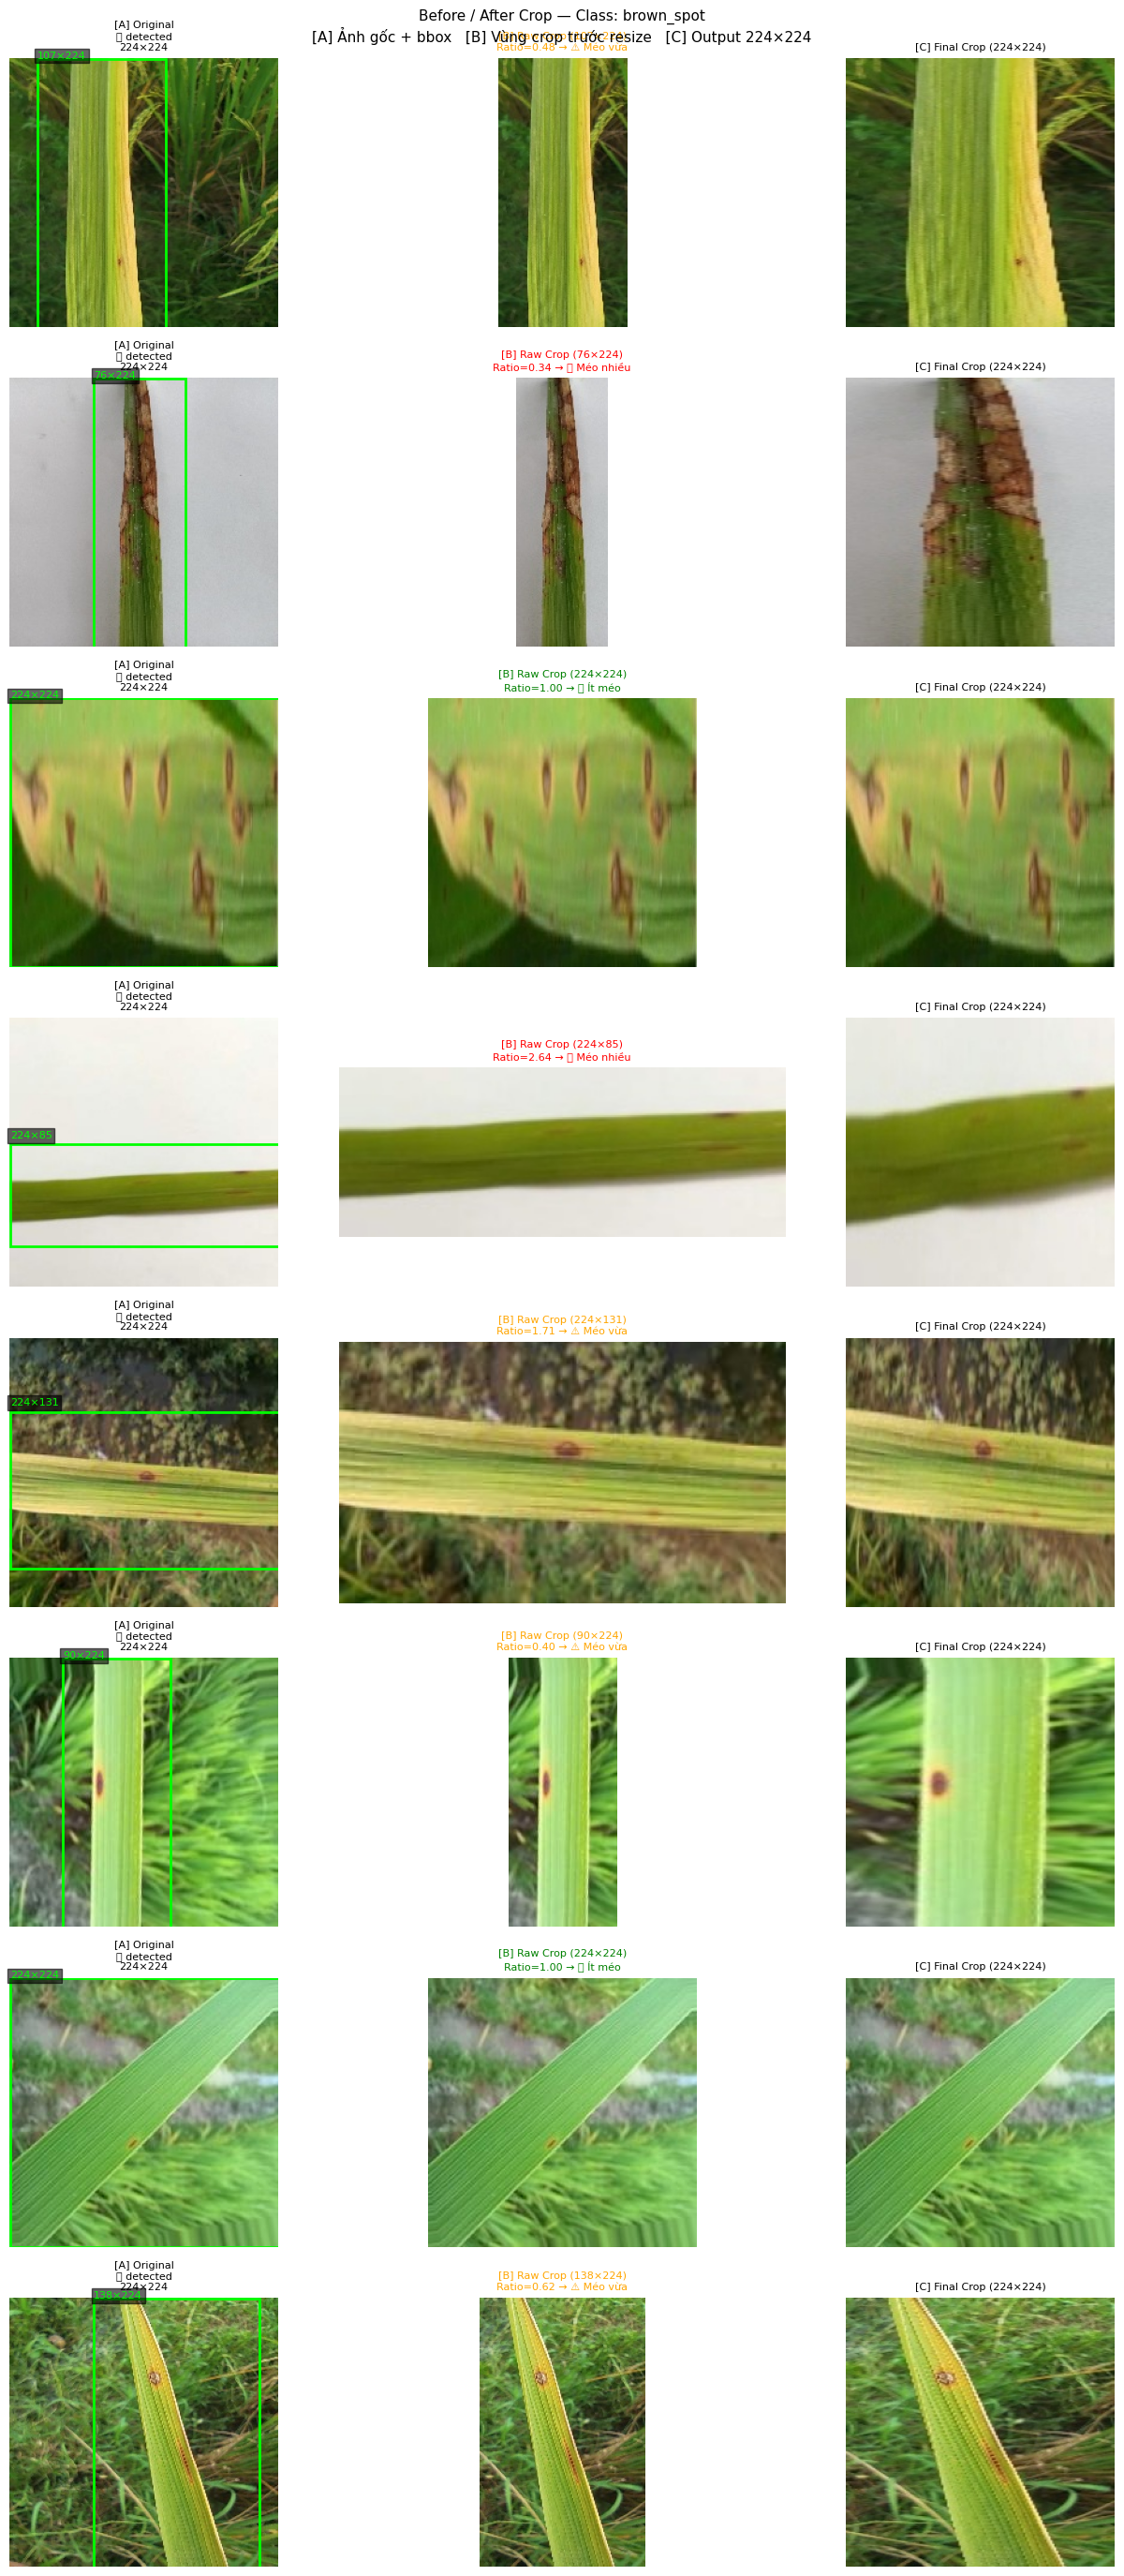

✅ Saved → crop_inspect_brown_spot.png


In [3]:
# ── Chọn class và số ảnh muốn xem ────────────────────────────────────
INSPECT_CLASS  = "brown_spot"   # ← Đổi class muốn xem
N_SAMPLES      = 8              # Số ảnh hiển thị
random.seed(42)

src_dir  = os.path.join(SOURCE_DIR,  INSPECT_CLASS)
crop_dir = os.path.join(CROPPED_DIR, INSPECT_CLASS)

# Lấy ảnh có cả src lẫn crop
src_imgs  = set(os.listdir(src_dir))
crop_imgs = set(os.listdir(crop_dir))
common    = list(src_imgs & crop_imgs)
samples   = random.sample(common, min(N_SAMPLES, len(common)))

fig, axes = plt.subplots(N_SAMPLES, 3, figsize=(14, N_SAMPLES * 3.5))

for row, img_file in enumerate(samples):
    # Load ảnh gốc
    src_path  = os.path.join(src_dir, img_file)
    crop_path = os.path.join(crop_dir, img_file)
    
    img_orig = cv2.imread(src_path)
    img_orig_rgb = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
    h_orig, w_orig = img_orig.shape[:2]
    
    img_crop = cv2.imread(crop_path)
    img_crop_rgb = cv2.cvtColor(img_crop, cv2.COLOR_BGR2RGB)
    
    # Detect lại để vẽ bbox lên ảnh gốc
    results = yolo.predict(img_orig, conf=CONF_THRESHOLD, verbose=False)
    boxes   = results[0].boxes
    
    detected  = False
    box_xyxy  = None
    crop_ratio = None  # tỉ lệ w/h của vùng crop gốc
    
    if boxes is not None and len(boxes) > 0:
        xyxy  = boxes.xyxy.cpu().numpy()
        areas = (xyxy[:, 2]-xyxy[:, 0]) * (xyxy[:, 3]-xyxy[:, 1])
        best  = np.argmax(areas)
        x1,y1,x2,y2 = xyxy[best].astype(int)
        x1=max(0,x1-PADDING); y1=max(0,y1-PADDING)
        x2=min(w_orig,x2+PADDING); y2=min(h_orig,y2+PADDING)
        box_xyxy   = (x1,y1,x2,y2)
        crop_w     = x2 - x1
        crop_h     = y2 - y1
        crop_ratio = crop_w / crop_h  # <0.5 = lá dọc, >2.0 = lá ngang
        detected   = True
    
    # ── Cột A: Ảnh gốc + bbox ────────────────────────────────────────
    ax_orig = axes[row, 0]
    ax_orig.imshow(img_orig_rgb)
    if box_xyxy:
        x1,y1,x2,y2 = box_xyxy
        rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                                   linewidth=2, edgecolor='lime', facecolor='none')
        ax_orig.add_patch(rect)
        ax_orig.text(x1, max(y1-5,0), f"{crop_w}×{crop_h}",
                     color='lime', fontsize=8,
                     bbox=dict(fc='black', alpha=0.6, pad=2))
    label_orig = f"{'✅ detected' if detected else '⚠️ fallback'}\n{w_orig}×{h_orig}"
    ax_orig.set_title(f"[A] Original\n{label_orig}", fontsize=8)
    ax_orig.axis('off')
    
    # ── Cột B: Vùng crop trước khi resize (extract lại) ───────────────
    ax_raw = axes[row, 1]
    if box_xyxy:
        x1,y1,x2,y2 = box_xyxy
        raw_crop = img_orig_rgb[y1:y2, x1:x2]
        ax_raw.imshow(raw_crop)
        
        # Đánh giá mức độ méo khi resize về 224x224
        stretch_factor = max(crop_ratio, 1/crop_ratio)  # luôn >= 1
        if stretch_factor < 1.5:
            distort_label = "✅ Ít méo"
            distort_color = "green"
        elif stretch_factor < 2.5:
            distort_label = "⚠️ Méo vừa"
            distort_color = "orange"
        else:
            distort_label = "❌ Méo nhiều"
            distort_color = "red"
        
        ax_raw.set_title(
            f"[B] Raw Crop ({crop_w}×{crop_h})\nRatio={crop_ratio:.2f} → {distort_label}",
            fontsize=8, color=distort_color
        )
    else:
        ax_raw.imshow(img_orig_rgb)
        ax_raw.set_title("[B] Fallback (full image)", fontsize=8, color='orange')
    ax_raw.axis('off')
    
    # ── Cột C: Ảnh crop 224×224 final ────────────────────────────────
    ax_crop = axes[row, 2]
    ax_crop.imshow(img_crop_rgb)
    ax_crop.set_title(f"[C] Final Crop (224×224)", fontsize=8)
    ax_crop.axis('off')

plt.suptitle(f'Before / After Crop — Class: {INSPECT_CLASS}\n'
             f'[A] Ảnh gốc + bbox   [B] Vùng crop trước resize   [C] Output 224×224',
             fontsize=11)
plt.tight_layout()
plt.savefig(f'crop_inspect_{INSPECT_CLASS}.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"✅ Saved → crop_inspect_{INSPECT_CLASS}.png")

## 2. Scan toàn bộ dataset — tìm ảnh bị kéo giãn méo nhiều nhất

In [4]:
# ── Scan 200 ảnh mỗi class, tính tỉ lệ méo ───────────────────────────
SCAN_PER_CLASS = 200   # Số ảnh scan mỗi class (tăng để chính xác hơn)
random.seed(0)

distortion_report = {}  # class → list of (img_file, ratio, stretch_factor)

for class_name in CLASS_NAMES:
    src_dir = os.path.join(SOURCE_DIR, class_name)
    if not os.path.isdir(src_dir):
        continue
    
    all_imgs = [f for f in os.listdir(src_dir)
                if f.lower().endswith(('.jpg','.jpeg','.png'))]
    samples  = random.sample(all_imgs, min(SCAN_PER_CLASS, len(all_imgs)))
    
    records = []
    for img_file in tqdm(samples, desc=class_name, ncols=70):
        img_path = os.path.join(src_dir, img_file)
        img      = cv2.imread(img_path)
        if img is None:
            continue
        h, w = img.shape[:2]
        
        results = yolo.predict(img, conf=CONF_THRESHOLD, verbose=False)
        boxes   = results[0].boxes
        
        if boxes is not None and len(boxes) > 0:
            xyxy  = boxes.xyxy.cpu().numpy()
            areas = (xyxy[:,2]-xyxy[:,0])*(xyxy[:,3]-xyxy[:,1])
            best  = np.argmax(areas)
            x1,y1,x2,y2 = xyxy[best].astype(int)
            x1=max(0,x1-PADDING); y1=max(0,y1-PADDING)
            x2=min(w,x2+PADDING); y2=min(h,y2+PADDING)
            cw = x2-x1; ch = y2-y1
            if ch > 0:
                ratio   = cw / ch
                stretch = max(ratio, 1/ratio)
                records.append((img_file, ratio, stretch))
    
    distortion_report[class_name] = records

print("\n✅ Scan complete")

tungro: 100%|███████████████████████| 200/200 [00:13<00:00, 14.88it/s]


✅ Scan complete


In [5]:
# ── Thống kê méo theo class ───────────────────────────────────────────
print("\n" + "="*70)
print(f"{'CLASS':<25} {'SCAN':>6} {'✅<1.5':>8} {'⚠️1.5-2.5':>10} {'❌>2.5':>8} {'AVG STRETCH':>12}")
print("="*70)

for cls in CLASS_NAMES:
    recs = distortion_report.get(cls, [])
    if not recs:
        continue
    stretches = [r[2] for r in recs]
    low  = sum(1 for s in stretches if s < 1.5)
    mid  = sum(1 for s in stretches if 1.5 <= s < 2.5)
    high = sum(1 for s in stretches if s >= 2.5)
    avg  = np.mean(stretches)
    print(f"{cls:<25} {len(recs):>6} {low:>8} {mid:>10} {high:>8} {avg:>12.2f}")

print("="*70)
print("\nStretch factor: 1.0=vuông, 2.0=kéo gấp đôi, 3.0=kéo gấp ba")


CLASS                       SCAN    ✅<1.5  ⚠️1.5-2.5    ❌>2.5  AVG STRETCH
bacterial_blight             190      103         67       20         1.60
barrow_brown_leaf_spot       198       92         84       22         1.66
brown_spot                   195      122         52       21         1.51
healthy                      174       74         67       33         1.80
leaf_blast                   189       92         70       27         1.67
leaf_scald                   196      101         76       19         1.64
leaf_smut                    194      162         32        0         1.22
rice_hispa                   188       93         74       21         1.67
sheath_blight                200       98         89       13         1.63
tungro                       133       96         23       14         1.46

Stretch factor: 1.0=vuông, 2.0=kéo gấp đôi, 3.0=kéo gấp ba


C:\Users\qahhn\AppData\Local\Temp\ipykernel_17124\3580818403.py:30: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\qahhn\AppData\Local\Temp\ipykernel_17124\3580818403.py:30: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\qahhn\AppData\Local\Temp\ipykernel_17124\3580818403.py:31: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('distortion_report.png', dpi=100, bbox_inches='tight')
C:\Users\qahhn\AppData\Local\Temp\ipykernel_17124\3580818403.py:31: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('distortion_report.png', dpi=100, bbox_inches='tight')


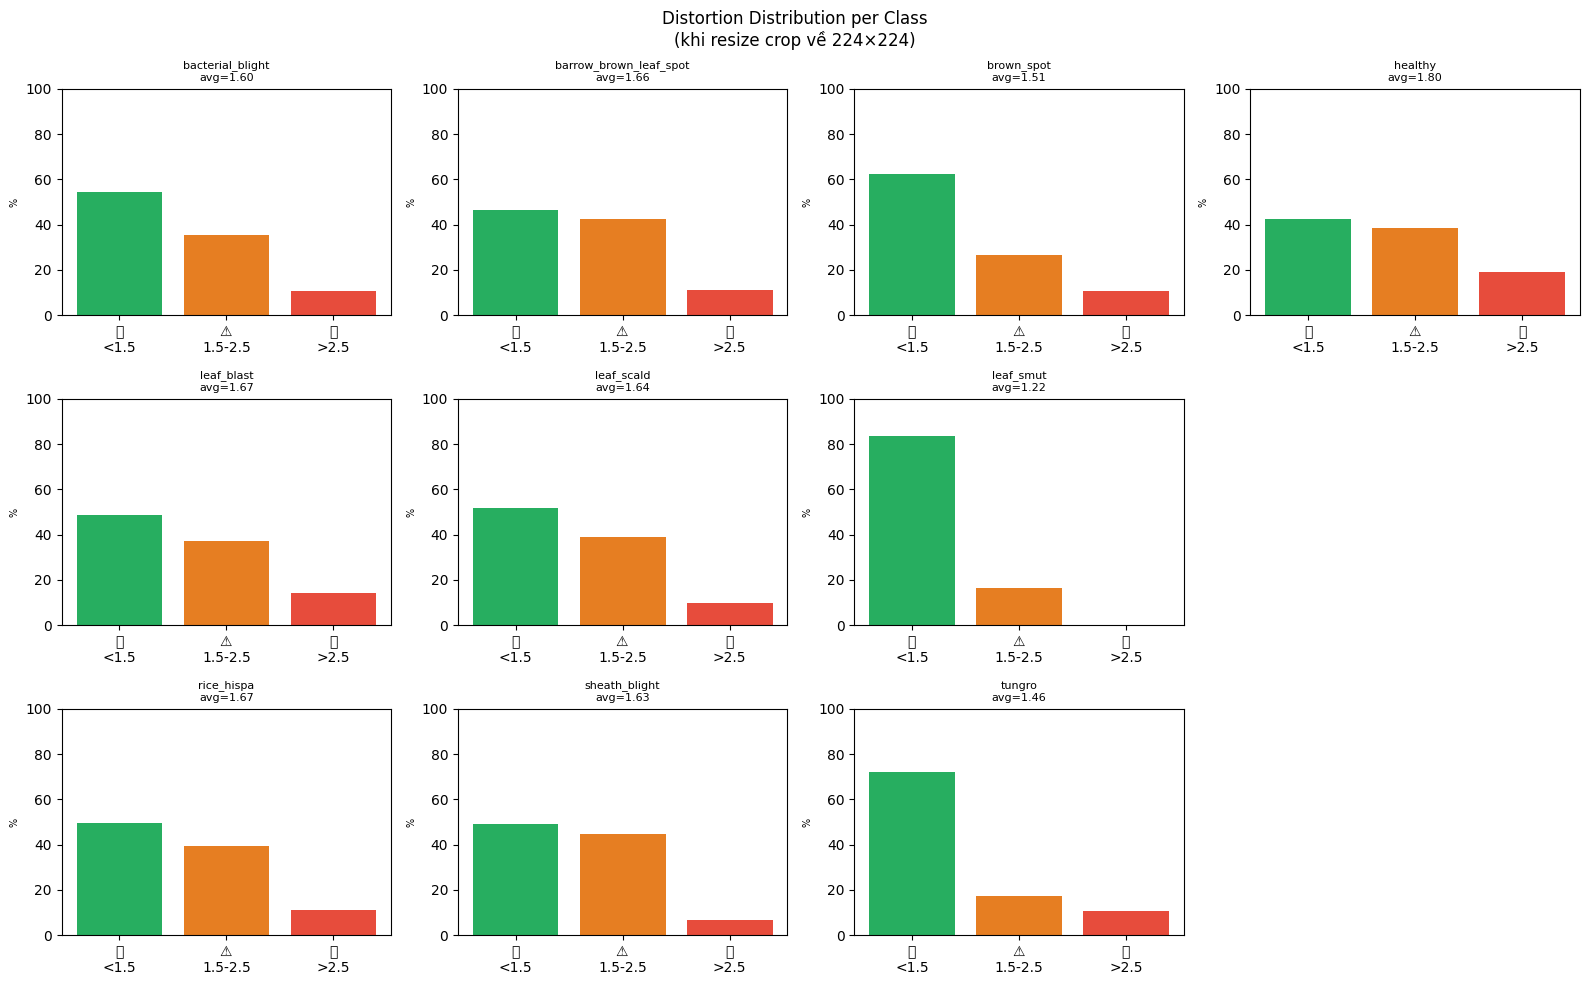

✅ Saved → distortion_report.png


In [6]:
# ── Visualize phân bố stretch factor theo class ───────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for ax, cls in zip(axes, CLASS_NAMES):
    recs = distortion_report.get(cls, [])
    if not recs:
        ax.axis('off')
        continue
    stretches = [r[2] for r in recs]
    
    # Màu theo mức độ
    n_low  = sum(1 for s in stretches if s < 1.5)
    n_mid  = sum(1 for s in stretches if 1.5 <= s < 2.5)
    n_high = sum(1 for s in stretches if s >= 2.5)
    total  = len(stretches)
    
    ax.bar(['✅\n<1.5', '⚠️\n1.5-2.5', '❌\n>2.5'],
           [n_low/total*100, n_mid/total*100, n_high/total*100],
           color=['#27ae60', '#e67e22', '#e74c3c'])
    ax.set_title(f"{cls}\navg={np.mean(stretches):.2f}", fontsize=8)
    ax.set_ylabel('%', fontsize=7)
    ax.set_ylim(0, 100)

# Ẩn subplot thừa
for i in range(len(CLASS_NAMES), len(axes)):
    axes[i].axis('off')

plt.suptitle('Distortion Distribution per Class\n(khi resize crop về 224×224)', fontsize=12)
plt.tight_layout()
plt.savefig('distortion_report.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Saved → distortion_report.png")

Top 8 ảnh bị kéo giãn méo nhất:
  [tungro] TUNGRO5_159_aug_0762.jpg — ratio=5.51, stretch=5.51x
  [rice_hispa] aug_0_1991.jpg — ratio=4.98, stretch=4.98x
  [healthy] 681935614_26558158033813463_2950594311528788682_n.jpg — ratio=0.20, stretch=4.94x
  [rice_hispa] aug_0_3721_aug_0134.jpg — ratio=4.31, stretch=4.31x
  [tungro] TUNGRO2_043_aug_1444.jpg — ratio=3.93, stretch=3.93x
  [leaf_scald] aug_0_943.jpg — ratio=3.68, stretch=3.68x
  [healthy] 20231006_163740.jpg — ratio=0.28, stretch=3.56x
  [rice_hispa] aug_0_7494.jpg — ratio=3.56, stretch=3.56x


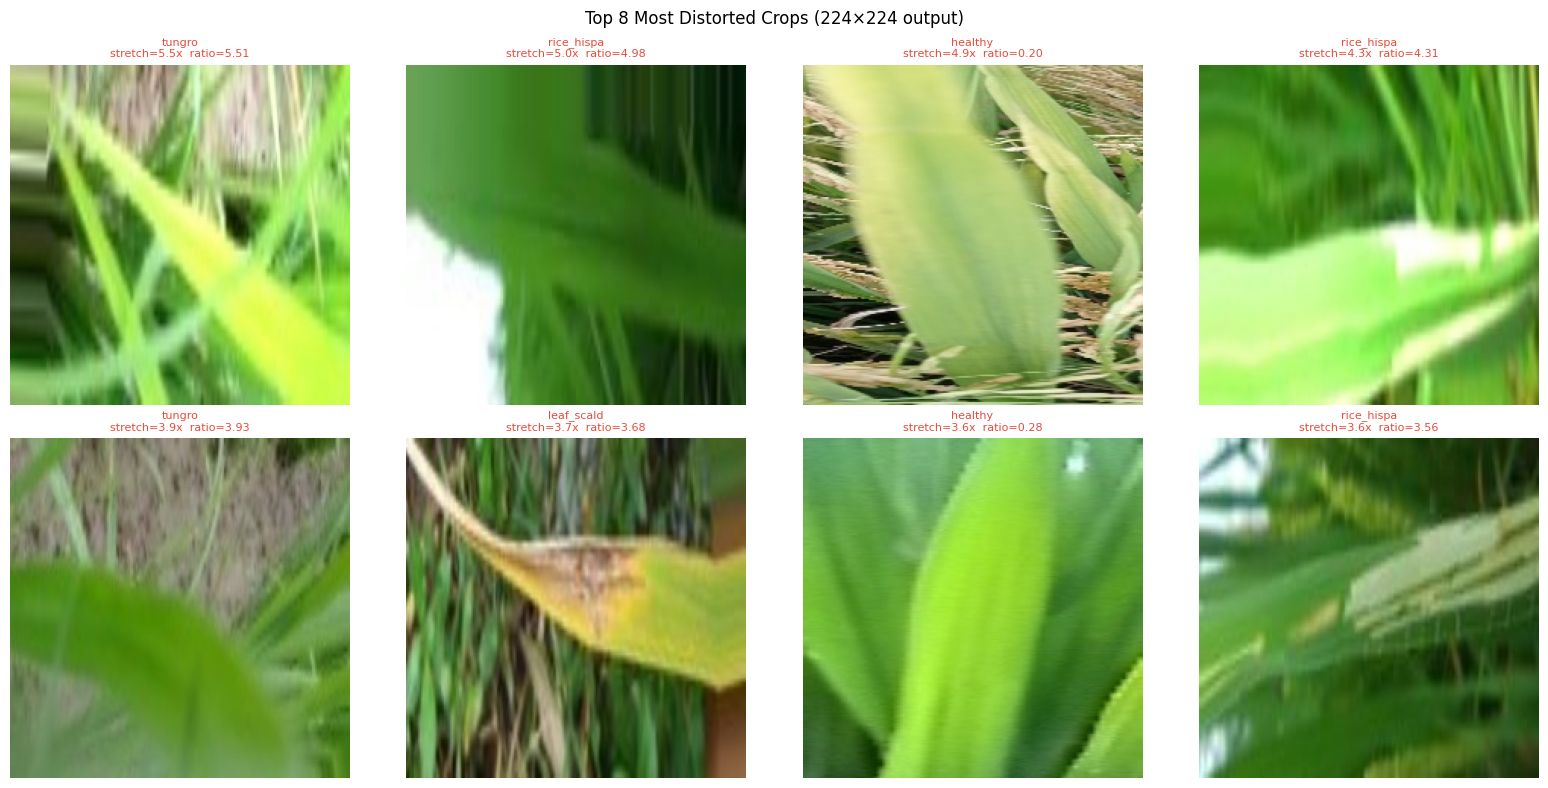

✅ Saved → worst_crops.png


In [7]:
# ── Hiển thị top 8 ảnh bị méo nhiều nhất ─────────────────────────────
all_records = []
for cls, recs in distortion_report.items():
    for img_file, ratio, stretch in recs:
        all_records.append((cls, img_file, ratio, stretch))

# Sort theo stretch factor giảm dần
all_records.sort(key=lambda x: x[3], reverse=True)
worst_8 = all_records[:8]

print("Top 8 ảnh bị kéo giãn méo nhất:")
for cls, f, ratio, stretch in worst_8:
    print(f"  [{cls}] {f} — ratio={ratio:.2f}, stretch={stretch:.2f}x")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, (cls, img_file, ratio, stretch) in zip(axes, worst_8):
    crop_path = os.path.join(CROPPED_DIR, cls, img_file)
    if not os.path.exists(crop_path):
        ax.axis('off')
        continue
    
    img = cv2.imread(crop_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    
    color = '#e74c3c' if stretch >= 2.5 else '#e67e22'
    ax.set_title(f"{cls}\nstretch={stretch:.1f}x  ratio={ratio:.2f}",
                 fontsize=8, color=color)
    ax.axis('off')

plt.suptitle('Top 8 Most Distorted Crops (224×224 output)', fontsize=12)
plt.tight_layout()
plt.savefig('worst_crops.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Saved → worst_crops.png")

## 3. So sánh: Stretch resize vs Letterbox resize

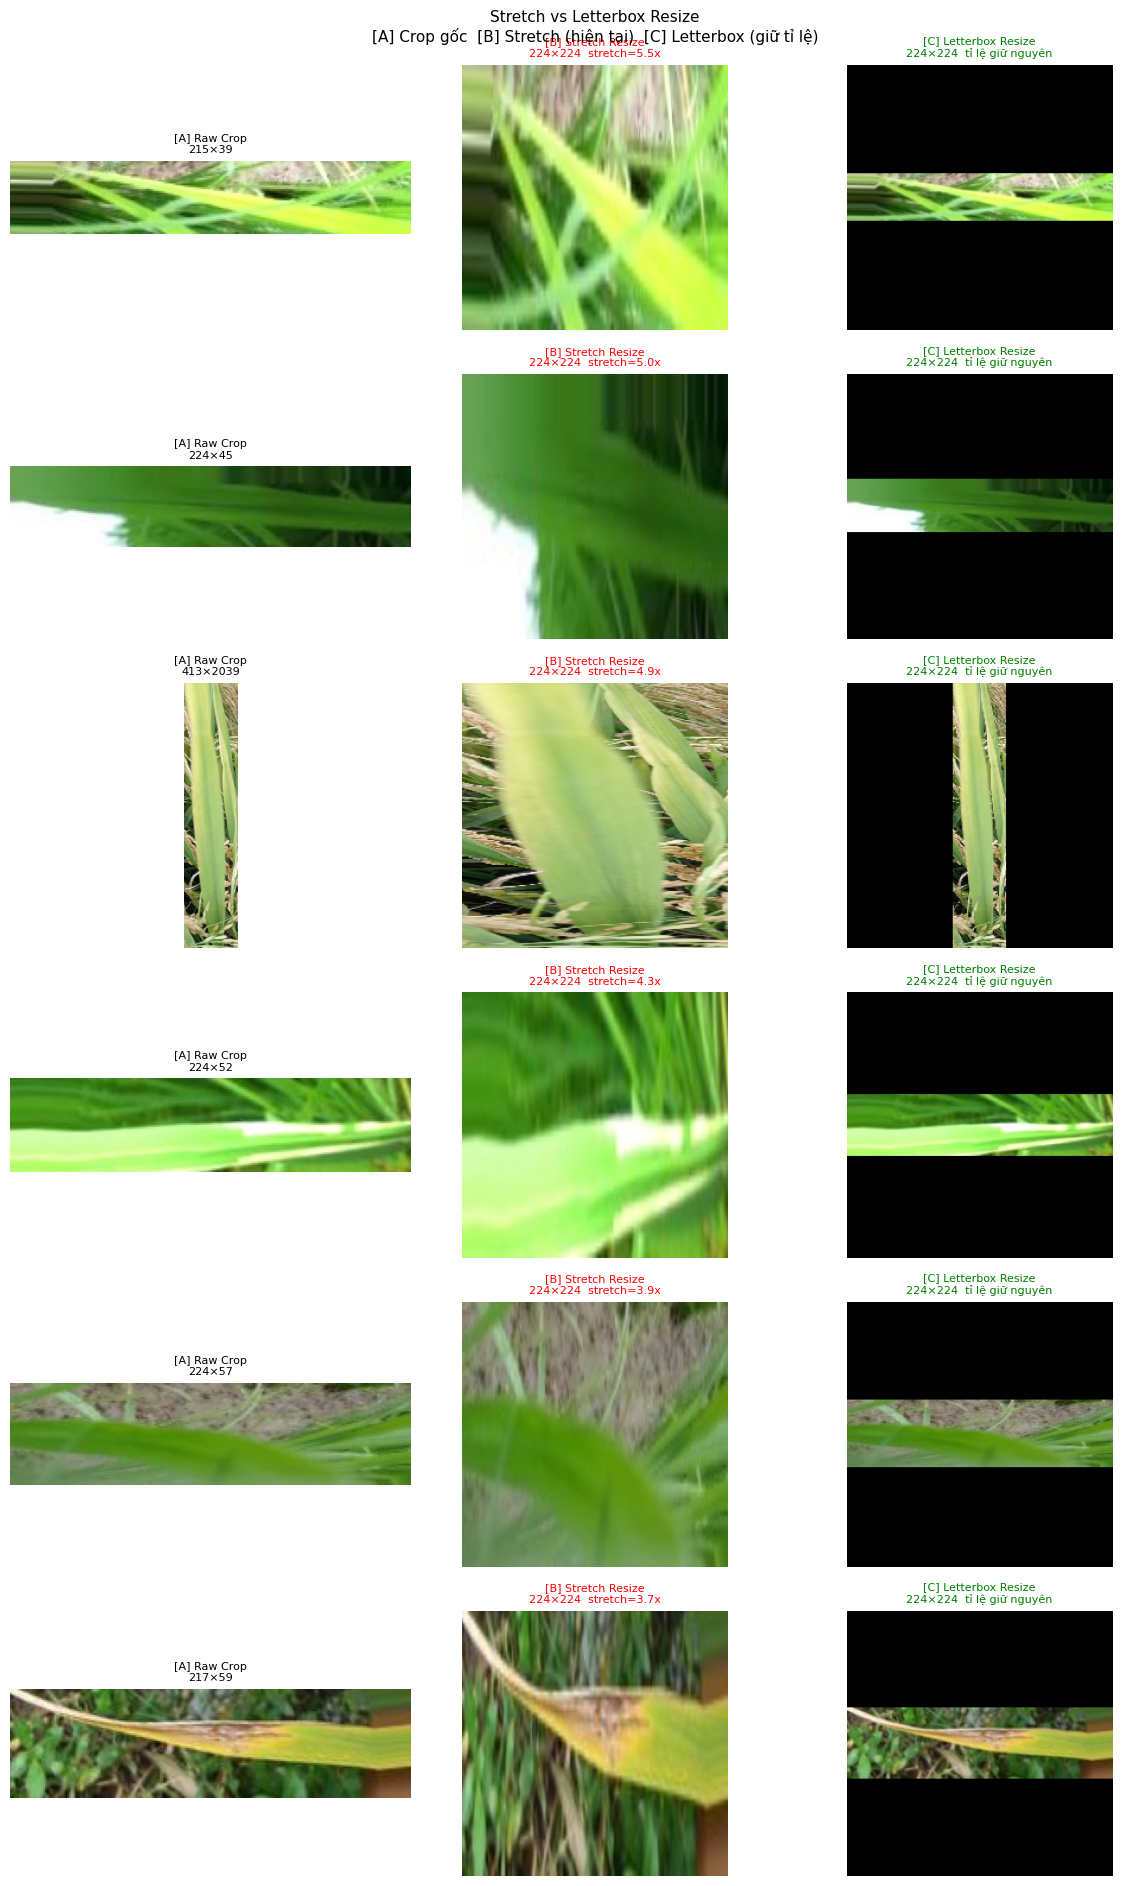

✅ Saved → stretch_vs_letterbox.png


In [8]:
# ── Letterbox function ────────────────────────────────────────────────
def letterbox_resize(img_bgr, size=224, pad_color=(0, 0, 0)):
    """
    Resize giữ tỉ lệ, pad thêm màu xung quanh → output size×size.
    """
    h, w = img_bgr.shape[:2]
    scale = size / max(h, w)
    new_w = int(w * scale)
    new_h = int(h * scale)
    
    resized = cv2.resize(img_bgr, (new_w, new_h))
    
    canvas = np.full((size, size, 3), pad_color, dtype=np.uint8)
    pad_top  = (size - new_h) // 2
    pad_left = (size - new_w) // 2
    canvas[pad_top:pad_top+new_h, pad_left:pad_left+new_w] = resized
    return canvas


# ── Lấy 6 ảnh có stretch cao để so sánh ──────────────────────────────
compare_records = [r for r in all_records if r[3] >= 2.0][:6]
if not compare_records:
    compare_records = all_records[:6]

fig, axes = plt.subplots(len(compare_records), 3,
                          figsize=(12, len(compare_records) * 3.2))
if len(compare_records) == 1:
    axes = axes.reshape(1, -1)

for row, (cls, img_file, ratio, stretch) in enumerate(compare_records):
    src_path = os.path.join(SOURCE_DIR, cls, img_file)
    img = cv2.imread(src_path)
    if img is None:
        continue
    
    # YOLO detect lại
    h_o, w_o = img.shape[:2]
    results = yolo.predict(img, conf=CONF_THRESHOLD, verbose=False)
    boxes   = results[0].boxes
    
    if boxes is not None and len(boxes) > 0:
        xyxy  = boxes.xyxy.cpu().numpy()
        areas = (xyxy[:,2]-xyxy[:,0])*(xyxy[:,3]-xyxy[:,1])
        best  = np.argmax(areas)
        x1,y1,x2,y2 = xyxy[best].astype(int)
        x1=max(0,x1-PADDING); y1=max(0,y1-PADDING)
        x2=min(w_o,x2+PADDING); y2=min(h_o,y2+PADDING)
        raw_crop = img[y1:y2, x1:x2]
    else:
        raw_crop = img
    
    stretch_224    = cv2.resize(raw_crop, (224, 224))
    letterbox_224  = letterbox_resize(raw_crop, 224)
    
    raw_rgb  = cv2.cvtColor(raw_crop,    cv2.COLOR_BGR2RGB)
    str_rgb  = cv2.cvtColor(stretch_224, cv2.COLOR_BGR2RGB)
    let_rgb  = cv2.cvtColor(letterbox_224, cv2.COLOR_BGR2RGB)
    
    axes[row,0].imshow(raw_rgb)
    axes[row,0].set_title(f"[A] Raw Crop\n{raw_crop.shape[1]}×{raw_crop.shape[0]}", fontsize=8)
    axes[row,0].axis('off')
    
    axes[row,1].imshow(str_rgb)
    axes[row,1].set_title(f"[B] Stretch Resize\n224×224  stretch={stretch:.1f}x",
                           fontsize=8, color='red' if stretch>=2.5 else 'orange')
    axes[row,1].axis('off')
    
    axes[row,2].imshow(let_rgb)
    axes[row,2].set_title("[C] Letterbox Resize\n224×224  tỉ lệ giữ nguyên",
                           fontsize=8, color='green')
    axes[row,2].axis('off')

plt.suptitle('Stretch vs Letterbox Resize\n'
             '[A] Crop gốc  [B] Stretch (hiện tại)  [C] Letterbox (giữ tỉ lệ)',
             fontsize=11)
plt.tight_layout()
plt.savefig('stretch_vs_letterbox.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Saved → stretch_vs_letterbox.png")

In [9]:
# ── Tổng kết ──────────────────────────────────────────────────────────
all_stretches = [r[3] for r in all_records]
pct_ok   = sum(1 for s in all_stretches if s < 1.5) / len(all_stretches) * 100
pct_mid  = sum(1 for s in all_stretches if 1.5 <= s < 2.5) / len(all_stretches) * 100
pct_bad  = sum(1 for s in all_stretches if s >= 2.5) / len(all_stretches) * 100

print("="*55)
print("DISTORTION SUMMARY (toàn bộ classes)")
print("="*55)
print(f"✅ Ít méo   (stretch <1.5) : {pct_ok:.1f}%")
print(f"⚠️  Méo vừa (stretch 1.5-2.5): {pct_mid:.1f}%")
print(f"❌ Méo nhiều (stretch >2.5) : {pct_bad:.1f}%")
print(f"\nAvg stretch factor : {np.mean(all_stretches):.2f}x")
print("="*55)

if pct_bad < 10:
    print("\n✅ Dataset đủ tốt để train với stretch resize")
elif pct_bad < 25:
    print("\n⚠️  Nên cân nhắc chuyển sang letterbox resize")
else:
    print("\n❌ Nên dùng letterbox resize — stretch đang làm méo nhiều ảnh")

DISTORTION SUMMARY (toàn bộ classes)
✅ Ít méo   (stretch <1.5) : 55.6%
⚠️  Méo vừa (stretch 1.5-2.5): 34.1%
❌ Méo nhiều (stretch >2.5) : 10.2%

Avg stretch factor : 1.59x

⚠️  Nên cân nhắc chuyển sang letterbox resize
